In [100]:
import  numpy as  np
import  pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

In [101]:
df=  pd.read_csv("loan_approval_data.csv")

In [102]:
df.index

RangeIndex(start=0, stop=1000, step=1)

In [103]:
# df.head()
# df.info()
# df.isnull().sum()
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

#  Handle missing  Values

In [104]:
# Separate numerical columns
num_cols = df.select_dtypes(include=["number"]).columns

# Separate categorical columns
cate_cols = df.select_dtypes(include=["object"]).columns


In [105]:
#  Fill  Null values using  imputer 
num_imputer = SimpleImputer(strategy='mean')
df[num_cols]= num_imputer.fit_transform(df[num_cols])

In [106]:
#  Fill Null values using  imputer 
categorical_imputer = SimpleImputer(strategy='most_frequent')
df[cate_cols] =categorical_imputer.fit_transform(df[cate_cols])


In [107]:
num_cols.size+cate_cols.size

20

#  EDA  Exploratory Data Analysis

In [108]:
#  remove Applicant_ID
df = df.drop("Applicant_ID", axis=1)

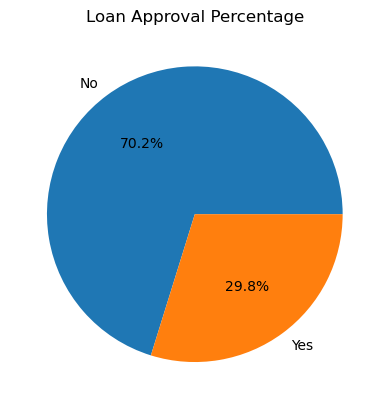

In [109]:
#  Percentage of   Succefully  approve Loan and  rejected

Loan_Status =  df["Loan_Approved"].value_counts()
plt.pie(
    Loan_Status,
    labels=["No" ,"Yes"],
    autopct='%1.1f%%'
)
plt.title('Loan Approval Percentage')
plt.show()

In [110]:
Gender_Count =df["Gender"].value_counts()

[Text(0, 0, '621'), Text(0, 0, '379')]

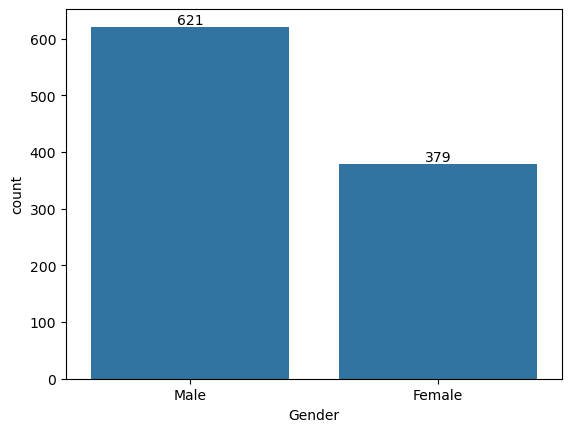

In [111]:
# check how many Applicant are Male And  Female. 
ax= sns.barplot(
    Gender_Count
)
ax.bar_label(ax.containers[0])


[Text(0, 0, '722'), Text(0, 0, '278')]

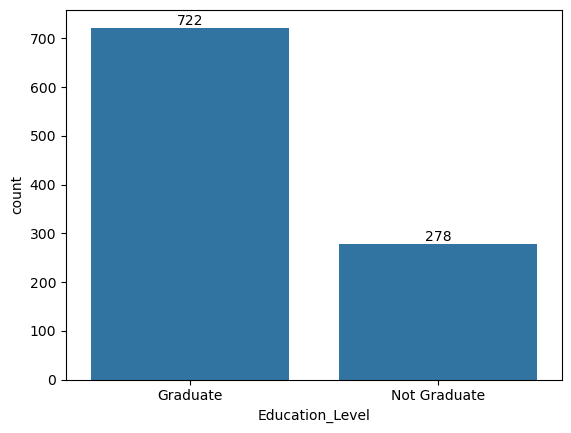

In [112]:
# check how many Applicant are Graduate And  Not  Graduate 
ax=sns.barplot(
    df["Education_Level"].value_counts()
)
ax.bar_label(ax.containers[0])


[Text(0, 0, '422'),
 Text(0, 0, '202'),
 Text(0, 0, '144'),
 Text(0, 0, '135'),
 Text(0, 0, '97')]

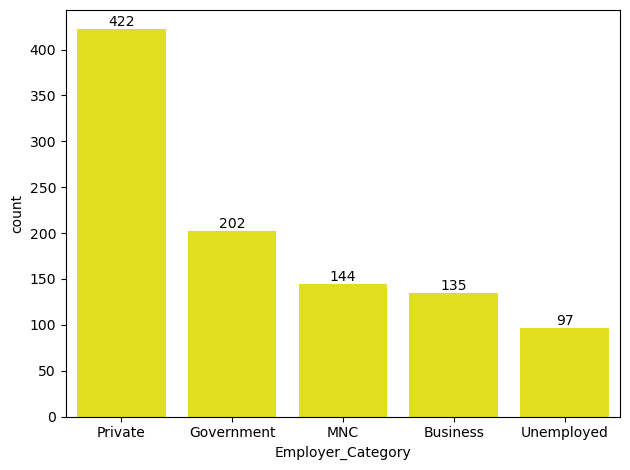

In [113]:
ax =sns.barplot(
     df["Employer_Category"].value_counts(),
    color="yellow"
    
)
plt.tight_layout()
ax.bar_label(ax.containers[0])

([<matplotlib.patches.Wedge at 0x1657dde9a90>,
 [Text(0.7729149196784404, 0.7826892914423133, 'Business'),
  Text(-0.6549223022268217, 0.8837854819162395, 'car'),
  Text(-1.0543739484534982, -0.31352125417996846, 'home'),
  Text(-0.1275747012008025, -1.0925770890941866, 'Education'),
  Text(0.9324457544711802, -0.5835622631465059, 'Personal')],
 [Text(0.4215899561882402, 0.42692143169580715, '25.2%'),
  Text(-0.35723034666917547, 0.4820648083179488, '19.9%'),
  Text(-0.575113062792817, -0.1710115931890737, '19.0%'),
  Text(-0.06958620065498318, -0.5959511395059199, '18.1%'),
  Text(0.5086067751660982, -0.3183066889890032, '17.8%')])

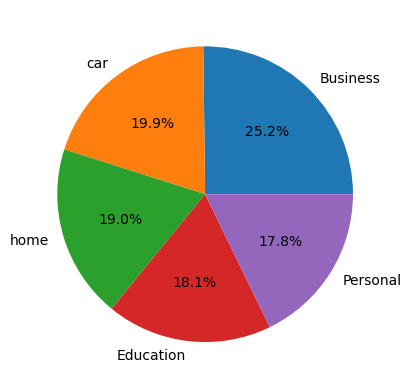

In [114]:
Purpose =["Business","car","home", "Education","Personal"]
plt.pie(
    df["Loan_Purpose"].value_counts(),
    autopct='%1.1f%%',
    labels=Purpose
)

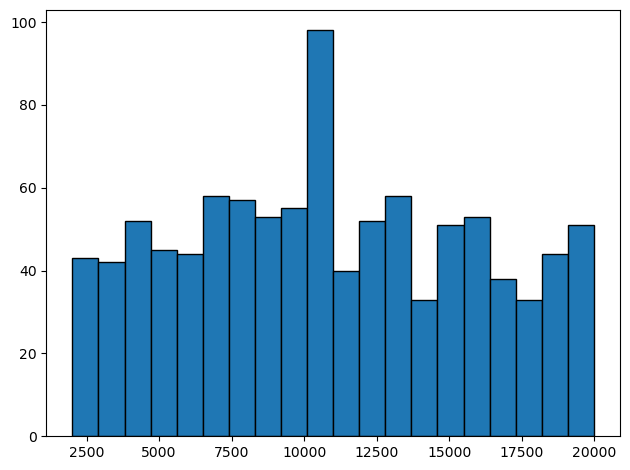

In [115]:
plt.hist(
    df["Applicant_Income"],
    bins =20,
    edgecolor="black"
)
plt.tight_layout()

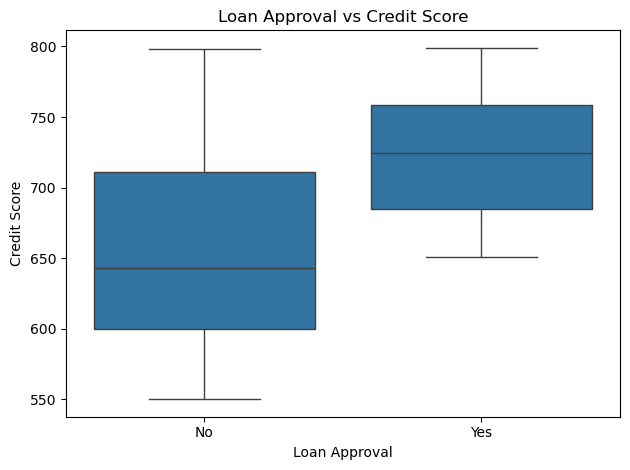

In [116]:
sns.boxplot(
    x=df["Loan_Approved"],
    y=df["Credit_Score"]
)
plt.title("Loan Approval vs Credit Score")
plt.xlabel("Loan Approval")
plt.ylabel("Credit Score")

plt.tight_layout()
plt.show()

#  Feature Encoding

In [117]:
from sklearn.preprocessing import OneHotEncoder , LabelEncoder

In [137]:
loan_encoder = LabelEncoder()
df["Loan_Approved"] = loan_encoder.fit_transform(df["Loan_Approved"])

education_encoder = LabelEncoder()

df["Education_Level"] = education_encoder.fit_transform(df["Education_Level"])




In [119]:

cols =["Employer_Category","Gender","Property_Area","Loan_Purpose","Employment_Status" ,"Marital_Status"]
encoder = OneHotEncoder(sparse_output=False, drop="first", handle_unknown='ignore')

Encoded = encoder.fit_transform(df[cols])

encoder_df = pd.DataFrame(Encoded , columns=encoder.get_feature_names_out(cols),index = df.index)

df =df.drop(cols,axis=1)

df = pd.concat([encoder_df,df],axis=1)

#  Correlation  Heatmap

In [120]:
num_col = df.select_dtypes(include=["number"])

In [121]:
corr_matrix = num_col.corr()

In [122]:
# Correlation heatmap
num_col.corr()["Loan_Approved"].sort_values(ascending =True)

DTI_Ratio                         -0.444783
Loan_Amount                       -0.126499
Loan_Term                         -0.086644
Loan_Purpose_Car                  -0.056416
Gender_Male                       -0.054342
Education_Level                   -0.052920
Employment_Status_Unemployed      -0.044464
Employment_Status_Salaried        -0.041428
Employer_Category_Government      -0.039187
Existing_Loans                    -0.034794
Dependents                        -0.023811
Age                               -0.022343
Employer_Category_Unemployed      -0.021468
Loan_Purpose_Education            -0.016684
Savings                           -0.013437
Property_Area_Semiurban           -0.012967
Employer_Category_Private         -0.003347
Employment_Status_Self-employed   -0.001337
Loan_Purpose_Home                  0.002118
Coapplicant_Income                 0.004230
Collateral_Value                   0.021868
Property_Area_Urban                0.025963
Marital_Status_Single           

In [123]:
#correlation  Heatmap

In [124]:
# plt.figure(figsize=(15, 15))
# sns.heatmap(corr_matrix, annot=True)
# plt.show()

#  Train  Test  split +  Feature scaling

In [125]:
X =df.drop("Loan_Approved" ,axis=1)
y =df["Loan_Approved"]

In [126]:
 # Train Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [127]:
# Feature Scaling 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

# Train Model & evaluate

In [128]:
from sklearn.linear_model import LogisticRegression 
log_model = LogisticRegression()
log_model.fit(X_train_scale,y_train)
y_pred = log_model.predict(X_test_scale)

In [129]:
# Evaluate Model
from sklearn.metrics import confusion_matrix, precision_score ,recall_score, f1_score,accuracy_score 

print("Logistic _regression")
print("----------  ----------- ")
print("precision_score", precision_score(y_test ,y_pred))
print("recall_score", recall_score(y_test ,y_pred))
print("f1_score", f1_score(y_test ,y_pred))
print("accuracy_score", accuracy_score(y_test ,y_pred))
print("confusion_matrix",confusion_matrix(y_test ,y_pred))

Logistic _regression
----------  ----------- 
precision_score 0.7833333333333333
recall_score 0.7704918032786885
f1_score 0.7768595041322314
accuracy_score 0.865
confusion_matrix [[126  13]
 [ 14  47]]


In [130]:
# Knn regression 
from sklearn.neighbors import KNeighborsClassifier 
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scale,y_train)
y_pred = knn_model.predict(X_test_scale)

In [131]:
# Evaluate Model
print("K Neighbors Classifier");
print("----------  ----------- ")
print("precision_score", precision_score(y_test ,y_pred))
print("recall_score", recall_score(y_test ,y_pred))
print("f1_score", f1_score(y_test ,y_pred))
print("accuracy_score", accuracy_score(y_test ,y_pred))
print("confusion_matrix",confusion_matrix(y_test ,y_pred))

K Neighbors Classifier
----------  ----------- 
precision_score 0.6274509803921569
recall_score 0.5245901639344263
f1_score 0.5714285714285714
accuracy_score 0.76
confusion_matrix [[120  19]
 [ 29  32]]


In [132]:
#  Naive Bayes 
from sklearn.naive_bayes import GaussianNB
naive_model = GaussianNB()

naive_model.fit(X_train_scale,y_train)
y_pred = naive_model.predict(X_test_scale)

In [133]:
# Evaluate Model
print("Naive Bayes");
print("----------  ----------- ")
print("precision_score", precision_score(y_test ,y_pred))
print("recall_score", recall_score(y_test ,y_pred))
print("f1_score", f1_score(y_test ,y_pred))
print("accuracy_score", accuracy_score(y_test ,y_pred))
print("confusion_matrix",confusion_matrix(y_test ,y_pred))

Naive Bayes
----------  ----------- 
precision_score 0.8035714285714286
recall_score 0.7377049180327869
f1_score 0.7692307692307693
accuracy_score 0.865
confusion_matrix [[128  11]
 [ 16  45]]


In [134]:
import pickle

models = {
    "Logistic Regression":log_model
}

# save model
with open("loan_model.pkl","wb") as file:
    pickle.dump(models, file)


# save scaler
with open("scaler.pkl","wb") as file:
    pickle.dump(scaler, file)


# save encoder
with open("encoder.pkl","wb") as file:
    pickle.dump(encoder, file)

In [ ]:
df.head()

,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Gender_Male,Property_Area_Semiurban,Property_Area_Urban,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,...,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,Loan_Approved
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,1,0
1,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,0,0
2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,0,1
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,0,0
4,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,0,1


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Employer_Category_Government     1000 non-null   float64
 1   Employer_Category_MNC            1000 non-null   float64
 2   Employer_Category_Private        1000 non-null   float64
 3   Employer_Category_Unemployed     1000 non-null   float64
 4   Gender_Male                      1000 non-null   float64
 5   Property_Area_Semiurban          1000 non-null   float64
 6   Property_Area_Urban              1000 non-null   float64
 7   Loan_Purpose_Car                 1000 non-null   float64
 8   Loan_Purpose_Education           1000 non-null   float64
 9   Loan_Purpose_Home                1000 non-null   float64
 10  Loan_Purpose_Personal            1000 non-null   float64
 11  Employment_Status_Salaried       1000 non-null   float64
 12  Employment_Status_Sel

In [99]:
print(le.classes_)

['Graduate' 'Not Graduate']
